# Training the U-Net Models for gap filling
<br>

* Runs in JupyterHub with GPU and image `pangeo/ml-notebook:2025.08.14`. 
* Runs in Colab [Open in Colab](https://colab.research.google.com/github/oceanhackweek/ohw25_proj_gap/blob/main/book/2-U-Net_Fit.ipynb)
* Runs in JupyterHub with GPU and image `pangeo/ml-notebook:2025.12.30` or current but requires the following changes:

```
os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
# required for memory not to crash during model training
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
```
and
```
# list all the available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Tell TF to only allocate memory as needed, preventing the cuDNN crash
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth successfully enabled for GPU.")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)
```
and setting batch size to 1 instead of 4. Note 4 works in old image and in Colab.
```
train_dataset = train_dataset.shuffle(buffer_size=512).batch(1)
```

### Packages

Install zarr for Colab. Need mindthegap installed for JupyterHub and Colab.

In [ ]:
# For Colab only Zarr v3 is fine
#pip install -q zarr

In [6]:
# Need for both Colab and JupyterHub
%pip install -q git+https://github.com/oceanhackweek/ohw25_proj_gap.git@main

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os

os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
# required for memory not to crash during model training
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
# silence some of the warnings about autotuning model selection
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_CPP_VMODULE"] = "conv_algorithm_picker=0,cuda_timer=0"

from xbatcher import BatchGenerator
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import dask.array as da
import xarray as xr
import zarr
import matplotlib.pyplot as plt
import mindthegap as mtg

### Check for Available GPUs

When training UNet models, using a GPU can significantly speed up the training process compared to using a CPU. The following code checks if your environment includes a GPU and uses it for training if available.  By default, TensorFlow will use the available GPU for training.


In [8]:
# list all the physical devices
physical_devices = tf.config.list_physical_devices()
print("All Physical Devices:", physical_devices)

# list all the available GPUs
gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

# Print infomation for available GPU if there exists any
if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("No GPU available")

# this is required in addition to the env var above to prevent memory crashing during training
if gpus:
  try:
    # Tell TF to only allocate memory as needed, preventing the cuDNN crash
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth successfully enabled for GPU.")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

All Physical Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'compute_capability': (7, 5), 'device_name': 'Tesla T4'}
Physical devices cannot be modified after being initialized


## Load the standardized data
This was created in the `1-U-Net_Data_Prep.ipynb` notebook. It has the sin and cos features, the masks for fake clouds, real clouds, valid pixels, and all the predictor features.

The data were standardized based on train dataset (mean and standard deviation) of 2015 to 2017 (3 years). Only numerical features and the label are standardized. Mean and standard deviation of _CHL_ and _masked_CHL_ are stored in a `.npy` file.

In [9]:
# Load from Google Buckets
import xarray as xr
zarr_stdized = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/2015_3_ArabSea.zarr",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True,
    chunks={}
)
ds_cropped = mtg.crop_to_multiple(zarr_stdized, multiple=8)
for v in ds_cropped.data_vars:
    if np.issubdtype(ds_cropped[v].dtype, np.floating):
        ds_cropped[v] = ds_cropped[v].astype("float32")
ds_cropped


Loaded Mean/Std Dictionary. Keys available: ['CHL', 'masked_CHL']


#### Function: `data_split`
This function selects the train, validation, and test data from the standardized data and splits the features and label. This is not the only way to set up the train, val and test datasets! Standardizing on the training is key so that there is not data leakage of training data into the validation and test data.

##### Parameters:
- `zarr_stdized`: Zarr file storing standardized features and label.
- `train_year`: the first year of train data
- `train_range`: length of train data in years
- `val_range`: length of validation data in years
- `test_range`: length of test data in years

So 2015 to 2017 for train 2018 for val and 2019 for test in example below.

##### Return:
- `X_train, X_val, X_test`: the predictor variables of the train/validation/test data
- `y_train, y_val, y_test`: the response variables of the train/validation/test data

In [ ]:
#the train year and range as defined in 1-U-Net_Data_Prep.ipynb
train_year = 2015
train_range = 3

# You define these
val_range = 1
test_range = 1

In [ ]:
def data_split(zarr_stdized, train_year, train_range, val_range, test_range):
    X_vars = list(zarr_stdized.keys())
    X_vars.remove('CHL')
    
    zarr_train = zarr_stdized.sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01'))
    X_train = []
    for var in X_vars:
        var = zarr_train[var].to_numpy() #can avoid
        X_train.append(np.where(np.isnan(var), 0.0, var))
    y_train = zarr_train.CHL.to_numpy()
    
    # Cast y_train to float32
    y_train = np.where(np.isnan(y_train), 0.0, y_train).astype(np.float32)
    y_train = np.expand_dims(y_train, axis=-1) #added
    
    # Force the entire X_train block to stay float32
    X_train = np.array(X_train, dtype=np.float32)
    X_train = np.moveaxis(X_train, 0, -1)
    del zarr_train
    
    zarr_val = zarr_stdized.sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01'))
    X_val = []
    for var in X_vars:
        var = zarr_val[var].to_numpy()
        X_val.append(np.where(np.isnan(var), 0.0, var))
    y_val = zarr_val.CHL.to_numpy()

    
    y_val = np.expand_dims(y_val, axis=-1) #added
    y_val = np.where(np.isnan(y_val), 0.0, y_val)
    X_val = np.array(X_val)
    X_val = np.moveaxis(X_val, 0, -1)
    del zarr_val
    
    zarr_test = zarr_stdized.sel(time=slice(f'{train_year+train_range+val_range}-01-01', f'{train_year+train_range+val_range+test_range}-01-01'))
    X_test= []
    for var in X_vars:
        var = zarr_test[var].to_numpy()
        X_test.append(np.where(np.isnan(var), 0.0, var))
    y_test = zarr_test.CHL.to_numpy()
    y_test = np.where(np.isnan(y_test), 0.0, y_test)
    y_test = np.expand_dims(y_test, axis=-1) #added
    X_test = np.array(X_test)
    X_test = np.moveaxis(X_test, 0, -1)
    del zarr_test, var

    return (X_train, y_train, 
            X_val, y_val,
            X_test, y_test)

Trying to use this instead of datasplit.

In [ ]:
# # this is loading into numpy arrays
X_train, y_train, X_val, y_val, X_test, y_test = data_split(ds_cropped, train_year, train_range, val_range, test_range)

In [ ]:
X_train.shape

### 3. Build model: U-Net
#### What is U-Net?
U-Net is a Convolutional Neural Network (CNN) architecture. CNN is a type of deep learning model that is particularly effective for visual data and high dimensional data analysis. It is powerful in capturing spatial hierarchies and patterns, and is widely used in computer vision tasks.
U-Net follows an autoencoder architecture, where the encoder half down-samples input images progressively and extracts features, while the decoder half constructs predictions based on these features. It is effective and accurate with rather limited data.

#### Model Architectures
The model uses three encoder layers of filter sizes 64, 128, 256, and three decoder layers of filter sizes 128, 64, 1. Each encoder block consists of two `Conv2D` layers, one `MaxPool2D` layer, and one `BatchNormalization` layer. Each decoder block consists of one `Conv2DTranspose` layer, one `Concatenate` layer, two `Conv2D` layer, and one `BatchNormalization` layer. The output of the final decoder layer is the gap-filled prediction of Chl-a.
- `Conv2D`: applies 2D convolution operations to the input. These layers are for feature detection (lines, edges, objects, patterns, etc.) in the encoder half, and for making predictions in the decoder half.
  `filters`: number of output channels and the number of features detected.
  `kernel_size`: size of the filters. All filters in this model are of size 3x3.
  `padding`: adds extra pixels to the input images. Padding of `same` ensures the same output dimensions as the input.
  `activation`: introduces non-linearity to neural networks that differentiate NNs from linear models. All layers other than the final layer uses 'ReLU', which outputs the input directly if positive and 0 if non-positive. The final layer uses 'Linear' due to potential negative values in log(Chl-a) predictions.
- `MaxPooling2D`: downsamples the input by taking the maximum in a given window (default is 2x2). It reduces complexity for future computations while retaining the most significant features. The output dimension is half of the input.
- `BatchNormalization`: normalizes the input. It reduces overfitting and improves the generalizability of a model.
- `Conv2DTranspose`: performs a "reverse" convolution and upsamples the input. The output dimension doubles the input.
- `Concatenate`: merges the upsampled feature maps with the feature maps from the corresponding encoder. It retains the higher-resolution features that were lost during downsampling.

#### Model Compilation
We use `.compile()` to configure the model for training.
`optimizer`: adjusts the parameters of the model during training to minimize the loss. We use `Adam`, which is known for faster convergence with its adaptively adjustment of the learning rate.
`loss`: define the loss function the model aims to minimize. We use mean squared error (MSE) due to its simplicity and effectiveness in the task.
`metrics`: other metrics, such as error or accuracy, we wish to evaluate during training. We apply mean absolute error (MAE) as another evaluator for performance.

In [11]:
def UNet(input_shape):
    inputs = Input(shape=input_shape)

    x = inputs

    filters = [64, 128, 256]
    ec_images = []

    for filter in filters:
        ec_images.append(x)
        x = layers.Conv2D(filters=filter,
                          kernel_size=(3, 3),
                          padding='same',
                          activation='relu'
                         )(x)
        x = layers.Conv2D(filters=filter,
                          kernel_size=(3, 3),
                          padding='same',
                          activation='relu'
                         )(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)

    for filter, ec_image in zip(filters[:-1][::-1], ec_images[::-1][:-1]):
        # x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
        x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)

        x = layers.concatenate([x, ec_image])
        x = layers.Conv2D(filters=filter,
                         kernel_size=(3, 3),
                         padding='same',
                         activation='relu'
                         )(x)
        x = layers.Conv2D(filters=filter,
                         kernel_size=(3, 3),
                         padding='same',
                         activation='relu'
                         )(x)
        x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
    x = layers.concatenate([x, ec_images[0]])
    x = layers.Conv2D(filters=filter,
                         kernel_size=(3, 3),
                         padding='same',
                         activation='relu'
                         )(x)
    outputs = layers.Conv2D(filters=1,
                      kernel_size=(3,3),
                      padding='same',
                      activation='linear'
                     )(x)

    unet_model = tf.keras.Model(inputs, outputs, name='U-net')
    unet_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return unet_model

In [12]:
#Variables needed for shape and generator
X_vars = list(ds_cropped.keys())
X_vars.remove('CHL')

lat_size = ds_cropped.sizes['lat']
lon_size = ds_cropped.sizes['lon']
num_features = len(X_vars)

# Define shape dynamically without loading data
input_shape = (lat_size, lon_size, num_features)
model = UNet(input_shape)
model.summary()


Model Input Shape defined as: (104, 152, 6)


In [ ]:
X_train.shape[1:]

#### Model training
We use `tf.data.Dataset.from_tensor_slices()` to shuffle the train data and slice the train and validation data according the provided batch size.
We then define earlystopping that will stop the training process if the performance is not improving, and then start fitting the model. The MSE and MAE are printed for each training epoch, and their values are recorded by `history`.

In [ ]:
# process train; in Colab and with 2025.08 pangeo ml-notebook image, batch(4) worked
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) 
train_dataset = train_dataset.shuffle(buffer_size=512).batch(4) #.map function allows passing any function

In [ ]:
# process val
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(4)

In [ ]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[early_stop])

#### Visualize losses
__Function__ `plot_losses`: Takes history as a parameter and plots the train and validation errors vs number of epochs (number of iterations for model training). This model evaluates the mean squared error and mean absolute error.

In [7]:
def plot_losses(history):
    history_keys = list(history.history.keys())
    plot_num = len(history_keys) // 2
    plt.figure(figsize=(5 * plot_num, 4))
    for i in range(plot_num):
        plt.subplot(1, plot_num, i + 1)
        train_key = history_keys[i]
        val_key = history_keys[i + plot_num]
        plt.plot(history.history[train_key], label=f'Train {train_key}')
        plt.plot(history.history[val_key], label=f'Validation {val_key[4:]}')
        plt.title(train_key)
        plt.xlabel('Epoch')
        plt.ylabel(train_key)
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.show()

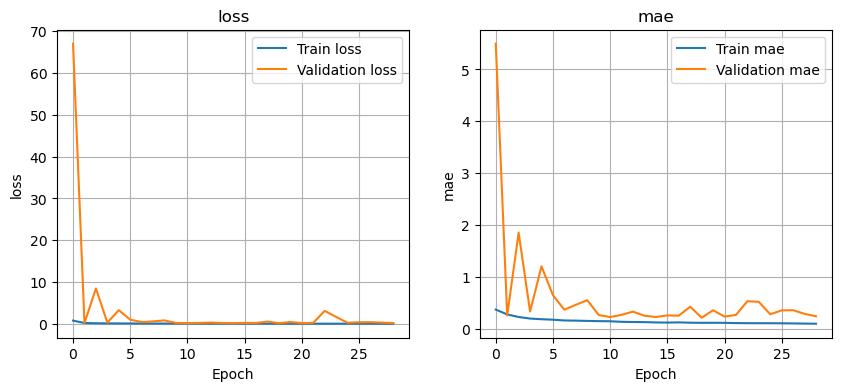

In [8]:
plot_losses(history)

#### Save trained model
The trained model is saved using `model.save` for easy access in future evaluation.
__Note__: Feel free to change the model path, but remember to create the folders before saving, or otherwise it may throw an error.

In [1]:
model_name = 'UNet_DoubleConv_mse'
import os
zarr_label = '2015_3_ArabSea'
folder_path= f'models/{zarr_label}'
os.makedirs(folder_path, exist_ok=True)
model_path = f'models/{zarr_label}/{model_name}.keras'
model.save(model_path)

NameError: name 'model' is not defined

#### Reload trained model
If you want to reload a specific model, use `tf.kera.models.load_model` along with the path to the model.

In [16]:
import tensorflow as tf
model = tf.keras.models.load_model(f'models/{zarr_label}/{model_name}.keras')

### 4. Model Evaluation
#### Evaluate test losses
__Function `test_loss`__: Takes the model and the test dataset as parameters and evaluates the model's performance. We use `model.evaluate` for performance of the model on unseen (test) dataset. The evaluation process calculates all loss and metrics compiled to the model (MAE and MSE in this case).

In [18]:
def evaluate_test_set():
    # Stream the test dataset using the RAW variables list
    ds_test = ds_cropped[raw_vars_to_keep].sel(time=slice(f'{train_year+train_range+val_range}-01-01', f'{train_year+train_range+val_range+test_range}-01-01'))
    test_batcher = BatchGenerator(ds_test, input_dims=input_dims, input_overlap=input_overlap)
    
    test_dataset = tf.data.Dataset.from_generator(
        make_tf_gen(test_batcher, X_vars),
        output_signature=output_signature
    ).batch(1)
    
    # Calculate exact steps so Keras knows when to stop gracefully
    test_steps = ds_test.sizes['time']
    
    # Evaluate without crashing RAM or throwing warnings
    test_mse, test_mae = model.evaluate(test_dataset, steps=test_steps)
    
    print(f"Test MSE: {test_mse}")
    print(f"Test MAE: {test_mae}")
    return test_mse, test_mae

test_mse, test_mae = evaluate_test_set()

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1696 - mae: 0.2179
Test MSE: 0.169624924659729
Test MAE: 0.21786005795001984


2026-06-30 00:20:51.436652: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
/srv/conda/envs/notebook/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-06-30 00:20:51.436682: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1873386972060316659
2026-06-30 00:20:51.436697: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13830777969316632388


In [21]:

test_mse, test_mae = test_loss(X_test, y_test, model)

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1696 - mae: 0.2179
Test MSE: 0.16962489485740662
Test MAE: 0.21786005795001984


2026-06-30 00:22:51.711337: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1873386972060316659
/srv/conda/envs/notebook/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-06-30 00:22:51.711369: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13830777969316632388


### Load original data
Will need for plotting.

In [22]:
import xarray as xr
zarr_ds = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True
)
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80

import numpy as np
zarr_ds = zarr_ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min,lon_max))  # choose long and lat
zarr_ds = mtg.crop_to_multiple(zarr_ds, multiple=8)
zarr_ds

<xarray.Dataset> Size: 25GB
Dimensions:                       (time: 16071, lat: 104, lon: 152)
Coordinates:
  * time                          (time) datetime64[ns] 129kB 1979-01-01 ... ...
  * lat                           (lat) float32 416B 31.0 30.75 ... 5.5 5.25
  * lon                           (lon) float32 608B 42.0 42.25 ... 79.5 79.75
Data variables: (12/27)
    CHL                           (time, lat, lon) float32 1GB ...
    CHL_cmes-cloud                (time, lat, lon) uint8 254MB ...
    CHL_cmes-gapfree              (time, lat, lon) float32 1GB ...
    CHL_cmes-land                 (lat, lon) uint8 16kB ...
    CHL_cmes-level3               (time, lat, lon) float32 1GB ...
    CHL_cmes_flags-gapfree        (time, lat, lon) float32 1GB ...
    ...                            ...
    ug_curr                       (time, lat, lon) float32 1GB ...
    v_curr                        (time, lat, lon) float32 1GB ...
    v_wind                        (time, lat, lon) float32 1GB ...
    vg_curr                       (time, lat, lon) float32 1GB ...
    wind_dir                      (time, lat, lon) float32 1GB ...
    wind_speed                    (time, lat, lon) float32 1GB ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

In [31]:
def plot_prediction_observed(zarr_stdized, zarr_label, model, date_to_predict):
    mean_std = np.load(f'{datadir}/{zarr_label}.npy',allow_pickle='TRUE').item()
    mean, std = mean_std['CHL'][0], mean_std['CHL'][1]
    zarr_date = zarr_stdized.sel(time=date_to_predict)
    X = []
    X_vars = list(zarr_stdized.keys())
    X_vars.remove('CHL')
    for var in X_vars:
        var = zarr_date[var].to_numpy()
        X.append(np.where(np.isnan(var), 0.0, var))
    X = np.array(X)
    X = np.moveaxis(X, 0, -1)

    true_CHL = np.log(zarr_ds.sel(time=date_to_predict)['CHL_cmes-level3'].to_numpy())
    # true_CHL = unstdize(true_CHL, mean, std)
    fake_cloud_flag = zarr_date.fake_cloud_flag.to_numpy()
    masked_CHL = np.where(fake_cloud_flag == 1, np.nan, true_CHL)
    # masked_CHL = unstdize(masked_CHL, mean, std)
    predicted_CHL = model.predict(X[np.newaxis, ...], verbose=0)[0]
    predicted_CHL = predicted_CHL[:,:,0]
    predicted_CHL = unstdize(predicted_CHL, mean, std)
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    diff = true_CHL - predicted_CHL

    flag = np.zeros(true_CHL.shape)
    flag = np.where(zarr_date['land_flag'] == 1, 0, flag)
    flag = np.where(zarr_date['valid_CHL_flag'] == 1, 2, flag)
    flag = np.where(zarr_date['real_cloud_flag'] == 1, 0, flag)
    flag = np.where(zarr_date['fake_cloud_flag'] == 1, 1, flag)

    vmax = np.nanmax((true_CHL, predicted_CHL))
    vmin = np.nanmin((true_CHL, predicted_CHL))

    extent = [42, 101.75, -11.75, 32]

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    im0 = axes[0, 0].imshow(true_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[0, 0].add_feature(cfeature.COASTLINE)
    axes[0, 0].set_xlabel('longitude')
    axes[0, 0].set_ylabel('latitude')
    axes[0, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 0].set_title('Observed Level-3 log Chl-a', size=14)

    im1 = axes[0, 1].imshow(flag, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 1].add_feature(cfeature.COASTLINE, color='white')
    axes[0, 1].set_xlabel('longitude')
    axes[0, 1].set_ylabel('latitude')
    axes[0, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 1].set_title('Land, Cloud, and Observed Flags After Applying Fake Cloud', size=13)

    im2 = axes[1, 0].imshow(predicted_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[1, 0].add_feature(cfeature.COASTLINE, color='white')
    axes[1, 0].imshow(np.where(flag == 1, np.nan, flag), vmax=2, vmin=0, extent=extent, origin='upper', interpolation='nearest', alpha=1)
    axes[1, 0].set_xlabel('longitude')
    axes[1, 0].set_ylabel('latitude')
    axes[1, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 0].set_title('Predicted log Chl-a from U-Net', size=14)

    vmin2 = -1
    vmax2 = 1
    im3 = axes[1, 1].imshow(diff, vmin=vmin2, vmax=vmax2, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu, interpolation='nearest')
    axes[1, 1].add_feature(cfeature.COASTLINE)
    axes[1, 1].set_xlabel('longitude')
    axes[1, 1].set_ylabel('latitude')
    axes[1, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 1].set_title('Difference Between log Observed and log Prediction\n(log observed - log prediction)', size=13)

    fig.subplots_adjust(right=0.76)
    cbar1_ax = fig.add_axes([0.79, 0.14, 0.025, 0.72])
    cbar1 = fig.colorbar(im0, cax=cbar1_ax)
    cbar1.ax.set_ylabel('log Chl-a (mg/m-3)', rotation=270, size=14, labelpad=16)

    cbar2_ax = fig.add_axes([0.86, 0.14, 0.025, 0.72])
    cbar2 = fig.colorbar(im1, cax=cbar2_ax)
    cbar2.ax.set_ylabel('land and real cloud = 0, fake cloud = 1, observed after masking = 2', rotation=270, size=14, labelpad=20)

    cbar3_ax = fig.add_axes([0.94, 0.14, 0.025, 0.72])
    cbar3 = fig.colorbar(im3, cax=cbar3_ax)
    cbar3.ax.set_ylabel('difference in log Chl-a', rotation=270, size=14, labelpad=16)
    plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


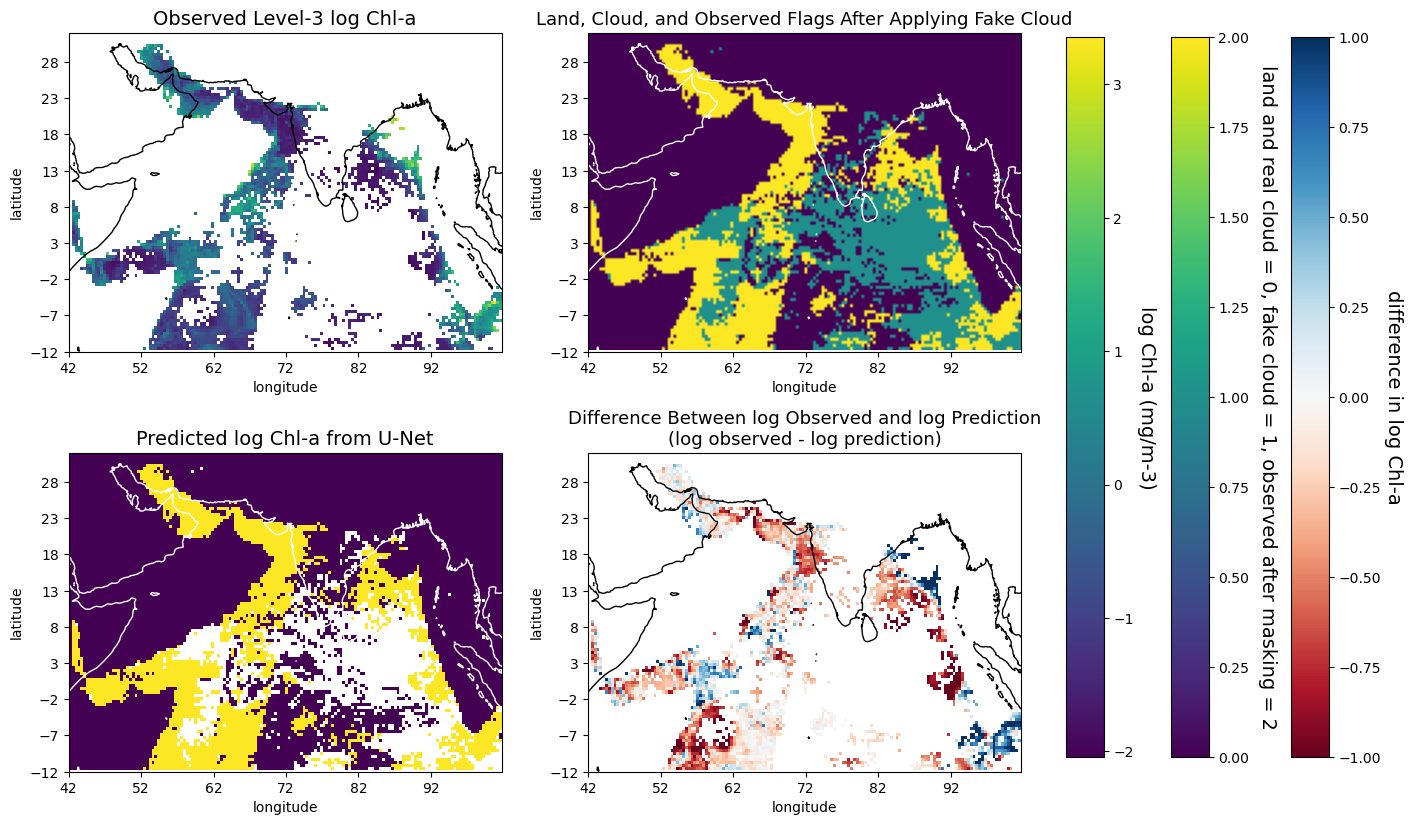

In [32]:
date = '2020-09-08'
plot_prediction_observed(ds_cropped, zarr_label, model, date)

- `plot_prediction_gapfill`:  predicts the gapfilled log(chl-a) of a given date. Plots a four-panel plot with the top left being the log gapfilled data from Copernicus GlobColour gapfree product, top right being the log U-Net prediction, bottom left being the log difference, and bottom right being the absolute difference.

In [33]:
def plot_prediction_gapfill(zarr_stdized, zarr_label, model, date_to_predict):
    mean_std = np.load(f'{datadir}/{zarr_label}.npy',allow_pickle='TRUE').item()
    mean, std = mean_std['CHL'][0], mean_std['CHL'][1]
    zarr_date = zarr_stdized.sel(time=date_to_predict)
    X = []
    X_vars = list(zarr_stdized.keys())
    X_vars.remove('CHL')
    X_vars[X_vars.index('masked_CHL')] = 'CHL'
    X_vars[X_vars.index('real_cloud_flag')] = 'a'
    X_vars[X_vars.index('fake_cloud_flag')] = 'real_cloud_flag'
    X_vars[X_vars.index('a')] = 'fake_cloud_flag'

    for var in X_vars:
        var = zarr_date[var].to_numpy()
        X.append(np.where(np.isnan(var), 0.0, var))
    valid_CHL_ind = X_vars.index('valid_CHL_flag')
    X[valid_CHL_ind] = da.where(X[X_vars.index('fake_cloud_flag')] == 1, 1, X[valid_CHL_ind])
    X[X_vars.index('fake_cloud_flag')] = np.zeros(X[0].shape)
    X_masked_CHL = np.log(zarr_ds.sel(time=date_to_predict)['CHL_cmes-level3'].to_numpy())
    X_masked_CHL = (X_masked_CHL - da.full(X_masked_CHL.shape, mean_std['masked_CHL'][0])) / da.full(X_masked_CHL.shape, mean_std['masked_CHL'][1])
    X_vars[X_vars.index('CHL')] = X_masked_CHL


    X = np.array(X)
    X = np.moveaxis(X, 0, -1)

    true_CHL = np.log(zarr_ds.sel(time=date_to_predict)['CHL_cmes-gapfree'].to_numpy())
    masked_CHL = np.log(zarr_ds.sel(time=date_to_predict)['CHL_cmes-level3'].to_numpy())
    predicted_CHL = model.predict(X[np.newaxis, ...], verbose=0)[0]
    predicted_CHL = predicted_CHL[:,:,0]
    predicted_CHL = unstdize(predicted_CHL, mean, std)
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    log_diff = true_CHL - predicted_CHL
    diff = np.exp(true_CHL) - np.exp(predicted_CHL)

    vmax = np.nanmax((true_CHL, predicted_CHL))
    vmin = np.nanmin((true_CHL, predicted_CHL))


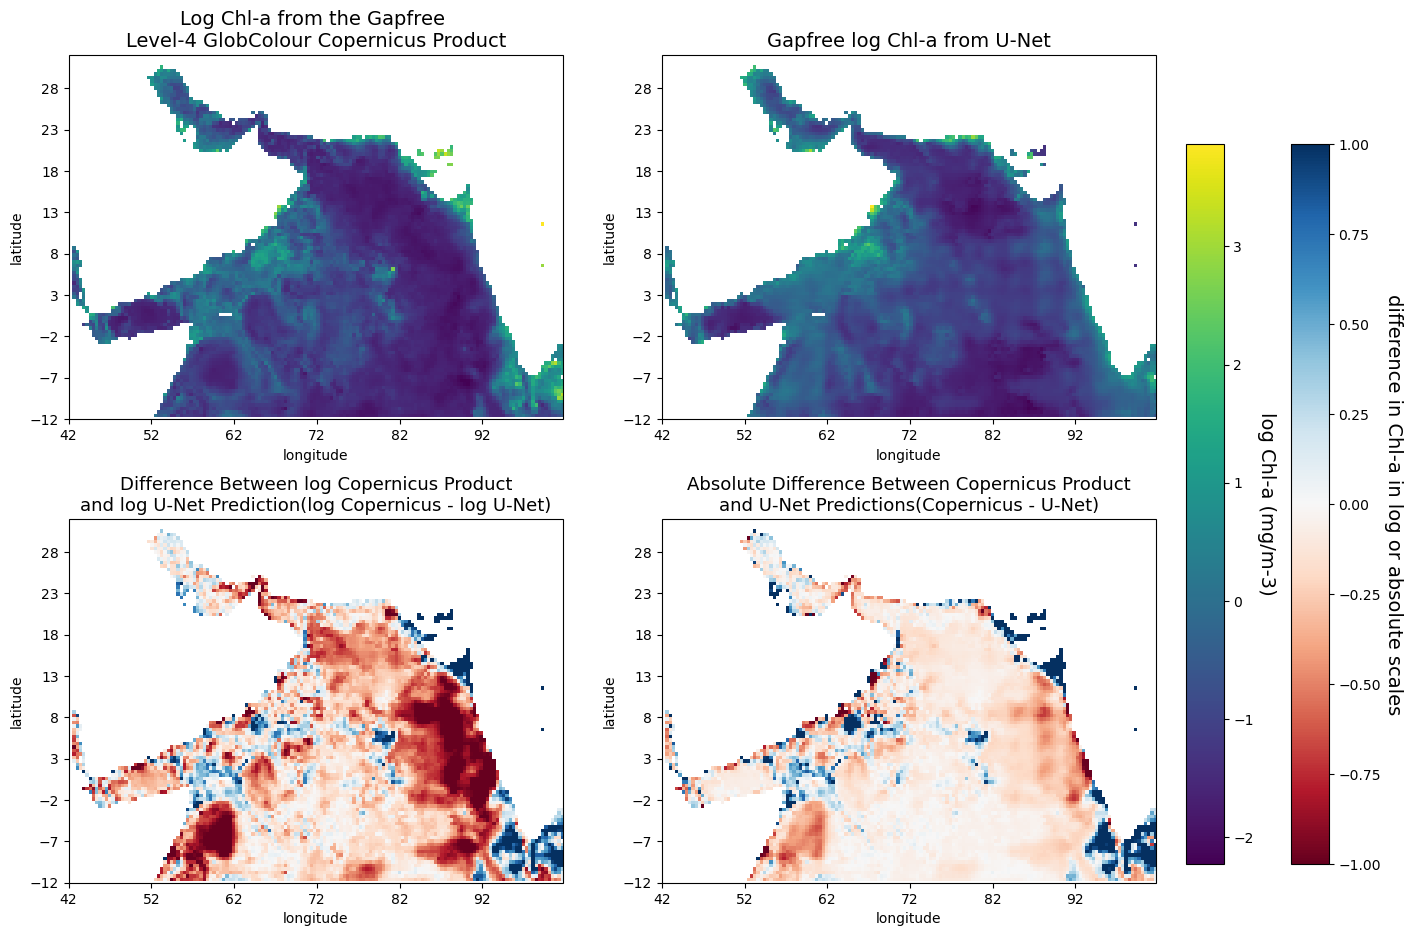

In [34]:
plot_prediction_gapfill(ds_cropped, zarr_label, model, date)

#### Plot Year-round Mean Absolute Difference
Such plots help evaluate the performance of the model on a daily basis and visualize seasonal trends.
- `yearly_MAD`: plots a line plot of the daily MAD between the observed and the U-Net prediction of the observed in a given year.

In [40]:
def yearly_MAD(zarr_stdized, zarr_label, year):
    mean_std = np.load(f'{datadir}/{zarr_label}.npy',allow_pickle='TRUE').item()
    mean, std = mean_std['CHL'][0], mean_std['CHL'][1]
    time_range = slice(f'{year}-01-01', f'{year}-12-31')
    zarr_time_range = zarr_stdized.sel(time=time_range)

    mae = []

    X = []
    X_vars = list(zarr_stdized.keys())
    X_vars.remove('CHL')
    for var in X_vars:
        var = zarr_time_range[var].to_numpy()
        X.append(np.where(np.isnan(var), 0.0, var))
    X = np.array(X)
    X = np.moveaxis(X, 0, -1)

    true_CHL = np.log(zarr_ds.sel(time=time_range)['CHL_cmes-level3'].to_numpy())
    fake_cloud_flag = zarr_time_range.fake_cloud_flag.to_numpy()
    predicted_CHL = model.predict(X, verbose=0)
    predicted_CHL = predicted_CHL.reshape(predicted_CHL.shape[:-1])
    predicted_CHL = unstdize(predicted_CHL, mean, std)
    predicted_CHL = np.where(fake_cloud_flag == 0, np.nan, predicted_CHL)
    for true, pred in zip(true_CHL, predicted_CHL):
        mae.append(compute_mae(true, pred))

    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.set_xlabel('Month')
    ax1.set_ylabel('MAD of log (Globcolour l3) - log (U-Net)', color=color)
    ax1.plot(mae, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    tick_pos = []
    tick_label = []
    total_day = 1
    tick_pos.append(total_day + 15)
    tick_label.append('1')
    for month in range(1, 12):
        total_day += calendar.monthrange(year, month)[1]
        plt.axvline(total_day, color='grey', alpha=0.3)
        tick_pos.append(total_day + 15)
        tick_label.append(str(month+1))
    plt.title(f'Observed (Level-3) CHL vs U-Net Predictions Year {year}')
    plt.xlim(1, len(mae))
    plt.xticks(tick_pos, tick_label)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


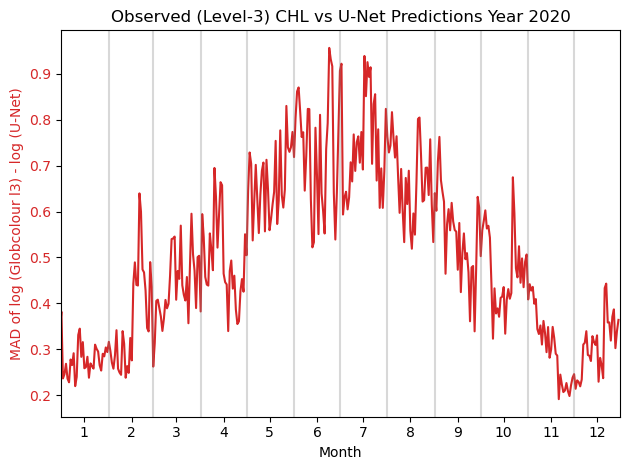

In [41]:
yearly_MAD(ds_cropped, zarr_label, 2020)

- `yearly_MAD_vs_cloud`: plots a line plot with two lines: the red line is the daily MAD between the Copernicus Gapfree product and the U-Net's gapfree prediction in a given year, and the blue line is the daily percentage of cloud/missing data of the same year.
- `get_cloud_perc`: a helper function that gets the cloud percentage in a given year.|

In [42]:
# def get_cloud_perc(zarr_stdized, year):
#     zarr_time_range = zarr_stdized.sel(time=str(year))

#     non_land_cnt = len(np.where(zarr_time_range['land_flag'][0] == 0)[0])
#     clouds = zarr_time_range['real_cloud_flag'].data
#     cloud_cnt = np.sum(clouds == 1, axis=(1, 2)).compute()
#     cloud_perc = cloud_cnt / non_land_cnt

#     return cloud_perc


# def yearly_MAD_vs_cloud(zarr_stdized, zarr_label, model, year):
#     mean_std = np.load(f'{datadir}/{zarr_label}.npy',allow_pickle='TRUE').item()
#     mean, std = mean_std['CHL'][0], mean_std['CHL'][1]
#     time_range = slice(f'{year}-01-01', f'{year}-12-31')

#     zarr_time_range = zarr_stdized.sel(time=time_range)

#     X = []
#     X_vars = list(zarr_stdized.keys())
#     X_vars.remove('CHL')
#     X_vars[X_vars.index('masked_CHL')] = 'CHL'
#     X_vars[X_vars.index('real_cloud_flag')] = 'a'
#     X_vars[X_vars.index('fake_cloud_flag')] = 'real_cloud_flag'
#     X_vars[X_vars.index('a')] = 'fake_cloud_flag'
#     for var in X_vars:
#         var = zarr_time_range[var].to_numpy()
#         X.append(np.where(np.isnan(var), 0.0, var))
#     valid_CHL_ind = X_vars.index('valid_CHL_flag')
#     X[valid_CHL_ind] = da.where(X[X_vars.index('fake_cloud_flag')] == 1, 1, X[valid_CHL_ind])
#     X[X_vars.index('fake_cloud_flag')] = np.zeros(X[0].shape)
#     X_masked_CHL = np.log(zarr_ds.sel(time=time_range)['CHL_cmes-level3'].to_numpy())
#     X_masked_CHL = (X_masked_CHL - da.full(X_masked_CHL.shape, mean_std['masked_CHL'][0])) / da.full(X_masked_CHL.shape, mean_std['masked_CHL'][1])
#     X_vars[X_vars.index('CHL')] = da.where(da.isnan(X_masked_CHL), 0.0, X_masked_CHL)
#     X = np.array(X)
#     X = np.moveaxis(X, 0, -1)

#     true_CHL = np.log(zarr_ds.sel(time=time_range)['CHL_cmes-gapfree'].to_numpy())
#     # fake_cloud_flag = zarr_date.fake_cloud_flag.to_numpy()
#     predicted_CHL = model.predict(X, verbose=0)
#     predicted_CHL = predicted_CHL.reshape(predicted_CHL.shape[:-1])
#     predicted_CHL = unstdize(predicted_CHL, mean, std)
#     flag = zarr_ds.sel(time=str(year))['CHL_cmes-level3'].to_numpy()
#     predicted_CHL = np.where(~np.isnan(flag), np.nan, predicted_CHL)
#     mae = []
#     for true, pred in zip(true_CHL, predicted_CHL):
#         mae.append(compute_mae(true, pred))

#     cloud_perc = get_cloud_perc(zarr_stdized, year)

#     fig, ax1 = plt.subplots()

#     color = 'tab:red'
#     ax1.set_xlabel('Month')
#     ax1.set_ylabel('MAD of log (Globcolour l4) - log (U-Net)', color=color)
#     ax1.plot(mae, color=color)
#     ax1.tick_params(axis='y', labelcolor=color)

#     ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

#     color = 'tab:blue'
#     ax2.set_ylabel('Cloud Percentage', color=color)  # we already handled the x-label with ax1
#     ax2.plot(cloud_perc, color=color)
#     ax2.tick_params(axis='y', labelcolor=color)

#     tick_pos = []
#     tick_label = []
#     total_day = 1
#     tick_pos.append(total_day + 15)
#     tick_label.append('1')
#     for month in range(1, 12):
#         total_day += calendar.monthrange(year, month)[1]
#         plt.axvline(total_day, color='grey', alpha=0.3)
#         tick_pos.append(total_day + 15)
#         tick_label.append(str(month+1))
#     plt.title(f'Copernicus GlobColour Gapfree CHL vs U-Net Predictions\nMAD vs Cloud Percentage Year {year}')
#     plt.xlim(1, len(mae))
#     plt.xticks(tick_pos, tick_label)

#     fig.tight_layout()  # otherwise the right y-label is slightly clipped
#     plt.show()
import numpy as np
import calendar
import matplotlib.pyplot as plt

def get_cloud_perc(zarr_stdized, year):
    zarr_time_range = zarr_stdized.sel(time=str(year))
    
    # Find the land mask to calculate the total valid ocean pixels
    if 'CHL_cmes-land' in zarr_stdized:
        # In IO.zarr, the land mask is a 2D grid (lat, lon)
        land_mask = zarr_stdized['CHL_cmes-land'].values
        non_land_cnt = np.sum(land_mask == 0)
    else:
        # Fallback: Count non-NaN pixels in the first day of gapfree data
        first_day = zarr_time_range['CHL_cmes-gapfree'].values[0]
        non_land_cnt = np.sum(~np.isnan(first_day))
        
    # Count the real clouds
    clouds = zarr_time_range['CHL_cmes-cloud'].values
    cloud_cnt = np.sum(clouds == 1, axis=(1, 2))
    
    # Calculate daily percentage
    cloud_perc = cloud_cnt / non_land_cnt

    return cloud_perc


def yearly_MAD_vs_cloud(zarr_stdized, zarr_label, model, year):
    # --- GLOBAL DICTIONARIES ---
    feature_stats = {
        'sst': [28.0, 2.0],  
        'so':  [36.0, 1.0],  
        'ug_curr': [0.0, 0.5],
        'v_curr': [0.0, 0.5]
    }
    
    datadir = "/home/jovyan/shared-public/mindthegap/data"
    mean_std = np.load(f'{datadir}/{zarr_label}.npy', allow_pickle=True).item()
    y_mean, y_std = mean_std['CHL'][0], mean_std['CHL'][1]
    
    zarr_year = zarr_stdized.sel(time=str(year))
    
    # --- DYNAMICALLY ENGINEER THE ENTIRE YEAR (VECTORIZED) ---
    
    # 1. Fake Clouds (Shift entire array by 10 days)
    real_clouds = zarr_year['CHL_cmes-cloud'].values
    fake_cloud_flag = np.roll(real_clouds, shift=-10, axis=0) 
    fake_cloud_flag = np.where(np.isnan(fake_cloud_flag), 0.0, fake_cloud_flag)
    
    # 2. True CHL & Masked CHL
    raw_true_chl = zarr_year['CHL_cmes-gapfree'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        log_true_chl = np.log(raw_true_chl)
        
    true_chl_std = (log_true_chl - y_mean) / y_std
    true_chl_std = np.where(np.isnan(true_chl_std), 0.0, true_chl_std)
    true_chl_std = np.where(np.isinf(true_chl_std), 0.0, true_chl_std)
    
    masked_chl = np.where(fake_cloud_flag == 1, 0.0, true_chl_std)
    
    # 3. Time Variables
    doy = zarr_year['time'].dt.dayofyear.values[:, np.newaxis, np.newaxis]
    sin_grid = np.broadcast_to(np.sin(2 * np.pi * doy / 365), raw_true_chl.shape).astype(np.float32)
    cos_grid = np.broadcast_to(np.cos(2 * np.pi * doy / 365), raw_true_chl.shape).astype(np.float32)

    # --- ASSEMBLE THE 6-CHANNEL INPUT ---
    X_vars = ['sst', 'so', 'sin_time', 'cos_time', 'masked_CHL', 'fake_cloud_flag'] 
    x_slice = []
    
    for var in X_vars:
        if var == 'masked_CHL':
            x_slice.append(masked_chl)
        elif var == 'fake_cloud_flag':
            x_slice.append(fake_cloud_flag)
        elif var == 'sin_time':
            x_slice.append(sin_grid)
        elif var == 'cos_time':
            x_slice.append(cos_grid)
        else:
            raw_val = np.where(np.isnan(zarr_year[var].values), 0.0, zarr_year[var].values)
            final_val = (raw_val - feature_stats[var][0]) / feature_stats[var][1] if var in feature_stats else raw_val
            x_slice.append(final_val)
            
    X = np.stack(x_slice, axis=-1).astype(np.float32)
    
    # --- PREDICT & EVALUATE ---
    
    # Predict in batches to protect GPU RAM
    predicted_CHL_std = model.predict(X, batch_size=8, verbose=0)
    predicted_CHL_std = predicted_CHL_std[:, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean
    
    # Grab the original arrays
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_year['CHL_cmes-gapfree'].values)
        flag = zarr_year['CHL_cmes-level3'].values
        
    # Mask prediction where the original Level-3 HAS data 
    # (This ensures we ONLY evaluate the U-Net's performance on the actual gaps)
    predicted_CHL = np.where(~np.isnan(flag), np.nan, predicted_CHL)
    
    mae = []
    for true, pred in zip(true_CHL, predicted_CHL):
        # Added the 'mtg.' prefix to prevent the NameError
        mae.append(mtg.compute_mae(true, pred))
        
    # Run the updated cloud percentage function
    cloud_perc = get_cloud_perc(zarr_stdized, year)

    # --- PLOT THE RESULTS ---
    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.set_xlabel('Month')
    ax1.set_ylabel('MAD of log (Globcolour l4) - log (U-Net)', color=color)
    ax1.plot(mae, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Cloud Percentage', color=color)  
    ax2.plot(cloud_perc, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    tick_pos = []
    tick_label = []
    total_day = 1
    tick_pos.append(total_day + 15)
    tick_label.append('1')
    for month in range(1, 12):
        total_day += calendar.monthrange(year, month)[1]
        plt.axvline(total_day, color='grey', alpha=0.3)
        tick_pos.append(total_day + 15)
        tick_label.append(str(month+1))
        
    plt.title(f'Copernicus GlobColour Gapfree CHL vs U-Net Predictions\nMAD vs Cloud Percentage Year {year}')
    plt.xlim(1, len(mae))
    plt.xticks(tick_pos, tick_label)

    fig.tight_layout() 
    plt.show()

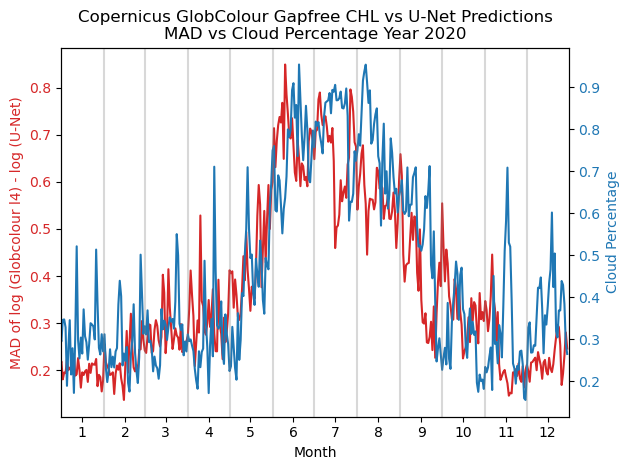

In [43]:
yearly_MAD_vs_cloud(ds_cropped, zarr_label, model, 2020)